# 00b — Stitch images acquired with different beamstop positions

All images are aligned and intensity-normalized to one explicitly selected reference image per polarization. The fixed detector mask never moves. Each beamstop mask may be shifted independently. Their union is the `mask_pixel` used for registration, normalization, and stitching.

The reference image remains unchanged wherever it is valid. Other images only fill its masked region; multiple valid fill values are averaged.


In [26]:
# Configure Qt before importing pyplot or any other GUI-aware library.
import os
import sys
from os.path import join

BASEFOLDER = os.path.abspath(os.getcwd())
LIBRARY_FOLDER = join(BASEFOLDER, "library")
if LIBRARY_FOLDER not in sys.path:
    sys.path.insert(0, LIBRARY_FOLDER)

from notebook_setup import configure_matplotlib_qt
MATPLOTLIB_BACKEND = configure_matplotlib_qt()
print("Matplotlib backend:", MATPLOTLIB_BACKEND)

import sys
import scipy
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

BASEFOLDER = os.path.abspath(os.getcwd())
sys.path.insert(0, join(BASEFOLDER, "library"))
from interactive import cimshow

from beamstop_stitching import shift_mask, stitch_images
from data_loading import Frame, SextantsNexusLoader, load_average
from image_preprocessing import fit_dark_frame, fit_horizontal_band, load_detector_masks

print("Base folder:", BASEFOLDER)


Matplotlib backend: qt5 (pyqt5)
Base folder: /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS


## Select the input images

In [31]:
# One position in these parallel lists defines one input to stitching.
# Every IMAGE_ID_GROUPS item may be one ID or a list of IDs to average first.


# Each raw input may use a different dark. A dark entry may also be a list.
# Dark entries are ignored only for matching preprocessed inputs; notebook 01a
# has already fitted and subtracted the dark from those files.




IMAGE_ID_GROUPS = [
    [569,571,605,607,609]+list(np.arange(575,602,2)),[570,572,606,608,610]+list(np.arange(576,603,2)),
    list(np.arange(660,709,2)),list(np.arange(661,710,2)),#center
    617,618,#down
    [622,625],[623,626],#up
    627,628,#left
    [630,633],[631,634],#right
    635,636,#bottom right
    638,639,#upper left
    641,642,#upper left diagonally
]
POLARIZATIONS = ["+", "-"]*(len(IMAGE_ID_GROUPS)//2)
# One loading mode per image group; raw and preprocessed inputs may be mixed.
INPUT_KINDS = ["raw"] * len(IMAGE_ID_GROUPS)
# Example: INPUT_KINDS[0] = "preprocessed"
DARK_ID_GROUPS = [[574,604]]*2+[[621,624,629,632,637,640,643]]*16
#
# The fixed detector mask is always mask_detector.png. Each raw input selects
# one mask_beamstop_<ID>.png, which can then be moved by the corresponding shift.
BEAMSTOP_MASK_IDS = [56500,56500]+[615]*(len(IMAGE_ID_GROUPS)-2)
# One non-negative dilation value per image group; 0 means no dilation.
BEAMSTOP_MASK_DILATIONS = [3] * len(IMAGE_ID_GROUPS)
MASK_SHIFTS = [
    (0,0),(0,0),
    (-23,0),(-23,0),
    (1, 0), (1, 0),
    (-46,3), (-46,3),
    (-18,-11), (-18,-11),
    (-43.0, 8.0),(-43.0, 8.0),
    (1.0, 4.0),(1.0, 4.0),
    (-39,-4),(-39,-4),
    (-9,-11),(-9,-11),
]

print(len(IMAGE_ID_GROUPS), len(POLARIZATIONS), len(INPUT_KINDS), len(DARK_ID_GROUPS), len(BEAMSTOP_MASK_IDS), len(BEAMSTOP_MASK_DILATIONS), len(MASK_SHIFTS))


18 18 18 18 18 18 18


In [32]:
RAW_FOLDER = "/nfs/ruche/sextants-soleil/com-sextants/COMET_20260902_Cocoons_Laser/"
RAW_FOLDER = '/media/riccardo/My Book/Beamtimes/26_09_SOLEIL/COMET_20260902_Cocoons_Laser/'

PREPROCESSED_FOLDER = join(BASEFOLDER, "processed", "cleaned_acquisitions")
MASK_FOLDER = join(BASEFOLDER, "processed", "mask_pixels")
USER = "rb"

input_count = len(IMAGE_ID_GROUPS)
if not all(len(values) == input_count for values in (
    POLARIZATIONS, INPUT_KINDS, DARK_ID_GROUPS, BEAMSTOP_MASK_IDS,
    BEAMSTOP_MASK_DILATIONS, MASK_SHIFTS
)):
    raise ValueError("All parallel input lists must have the same length")
print("Fixed detector mask:", join(MASK_FOLDER, "mask_detector.png"))
for index, values in enumerate(zip(
    IMAGE_ID_GROUPS, POLARIZATIONS, INPUT_KINDS, DARK_ID_GROUPS,
    BEAMSTOP_MASK_IDS, BEAMSTOP_MASK_DILATIONS, MASK_SHIFTS
)):
    image_ids, polarization, input_kind, dark_ids, beamstop_id, dilation, shift = values
    if input_kind not in ("raw", "preprocessed"):
        raise ValueError(f"INPUT_KINDS[{index}] must be raw or preprocessed")
    if not isinstance(dilation, (int, np.integer)) or dilation < 0:
        raise ValueError(f"BEAMSTOP_MASK_DILATIONS[{index}] must be a non-negative integer")
    print(f"input {index}: {polarization}, kind={input_kind}, dilation={dilation}, "
          f"images={image_ids}, darks={dark_ids}, "
          f"mask_beamstop_{beamstop_id}.png, shift={shift}")

Fixed detector mask: /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/processed/mask_pixels/mask_detector.png
input 0: +, kind=raw, dilation=3, images=[569, 571, 605, 607, 609, np.int64(575), np.int64(577), np.int64(579), np.int64(581), np.int64(583), np.int64(585), np.int64(587), np.int64(589), np.int64(591), np.int64(593), np.int64(595), np.int64(597), np.int64(599), np.int64(601)], darks=[574, 604], mask_beamstop_56500.png, shift=(0, 0)
input 1: -, kind=raw, dilation=3, images=[570, 572, 606, 608, 610, np.int64(576), np.int64(578), np.int64(580), np.int64(582), np.int64(584), np.int64(586), np.int64(588), np.int64(590), np.int64(592), np.int64(594), np.int64(596), np.int64(598), np.int64(600), np.int64(602)], darks=[574, 604], mask_beamstop_56500.png, shift=(0, 0)
input 2: +, kind=raw, dilation=3, images=[np.int64(660), np.int64(662), np.int64(664), np.int64(666), np.int64(668), np.int64(670), np.int64(672), np.int64(674), np.int64(676), np.int64(678), np.int64

## Load and average every input group


In [33]:
cimshow(mask_beamstop)

interactive(children=(FloatRangeSlider(value=(0.0, 1.0), description='contrast', layout=Layout(width='500px'),…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

In [34]:
# Dark fitting always uses this corner and excludes the fixed detector mask.
DARK_FIT_ROWS = slice(0, 1000)
DARK_FIT_COLUMNS = slice(0, 150)
DARK_FIT_PERCENTILE = 100
DARK_FIT_STRIDE = 1


def as_id_list(image_ids):
    if isinstance(image_ids, (list, tuple, np.ndarray)):
        return [int(image_id) for image_id in image_ids]
    return [int(image_ids)]


def average_preprocessed_files(image_ids):
    """Load and average cleaned images; masks always come from PNG files."""
    images = []
    energies = []
    sources = []
    for image_id in as_id_list(image_ids):
        input_file = join(PREPROCESSED_FOLDER, f"cleaned_ImId_{image_id:04d}_{USER}.npz")
        with np.load(input_file, allow_pickle=False) as saved:
            if "image" not in saved.files:
                raise KeyError(f"{input_file} does not contain an image array")
            images.append(np.asarray(saved["image"], dtype=float))

            if "energy_eV" in saved.files:
                energies.append(float(saved["energy_eV"]))
            else:
                raw_metadata = loader.load(image_id).metadata
                energies.append(float(raw_metadata["energy_eV"]))
                print(f"{input_file}: energy_eV missing; using raw NeXus metadata")
        sources.append(input_file)

    # These images were already cleaned independently in notebook 01a.
    averaged = np.mean(np.stack(images).astype(float), axis=0, dtype=np.float64)
    return averaged, float(np.mean(energies)), sources


loader = SextantsNexusLoader(RAW_FOLDER)
frames = []
mask_detectors = []
unshifted_mask_beamstops = []
mask_beamstops = []
mask_pixels = []
group_names = []
group_id_lists = []
energies_eV = []
dark_fit_plots = []

for input_index, values in enumerate(zip(
    IMAGE_ID_GROUPS, INPUT_KINDS, DARK_ID_GROUPS, BEAMSTOP_MASK_IDS,
    BEAMSTOP_MASK_DILATIONS, MASK_SHIFTS
)):
    image_ids, input_kind, dark_ids, beamstop_id, beamstop_dilation, beamstop_shift = values
    image_id_list = as_id_list(image_ids)
    group_name = "+".join(str(image_id) for image_id in image_id_list)

    if input_kind == "raw":
        # load_average accepts one ID or a list and always returns a float average.
        loaded = load_average(loader, image_ids)
        raw_average = np.asarray(loaded.image, dtype=float)
        dark_average = np.asarray(load_average(loader, dark_ids).image, dtype=float)
        
        mask_detector, mask_beamstop, _ = load_detector_masks(
            MASK_FOLDER, beamstop_id, raw_average.shape
        )
        
        # Keep the PNG mask unchanged until the common dilation below.
        image, scale, offset, dark_values, fitted_pixels = fit_dark_frame(
            raw_average,
            dark_average,
            DARK_FIT_ROWS,
            DARK_FIT_COLUMNS,
            percentile=DARK_FIT_PERCENTILE,
            stride=DARK_FIT_STRIDE,
            mask=mask_detector,
        )
        image_values = raw_average[DARK_FIT_ROWS, DARK_FIT_COLUMNS][
            ::DARK_FIT_STRIDE, ::DARK_FIT_STRIDE
        ].ravel()
        dark_fit_plots.append((group_name, dark_values, image_values, fitted_pixels, scale, offset))
        exposure = float(loaded.exposure)
        energy_eV = float(loaded.metadata["energy_eV"])
        source_name = loaded.source
        
    elif input_kind == "preprocessed":
        image, energy_eV, sources = average_preprocessed_files(image_ids)
        # Preprocessed files provide the image only. Masks are deliberately
        # reloaded from the same PNG files used for raw inputs.
        mask_detector, mask_beamstop, _ = load_detector_masks(
            MASK_FOLDER, beamstop_id, image.shape
        )
        exposure = 1.0
        source_name = sources[0]
    else:
        raise ValueError(f'Unknown input kind for input {input_index}: {input_kind}')

    # Raw and preprocessed inputs use the same image-dependent PNG treatment.
    if beamstop_dilation > 0:
        mask_beamstop = scipy.ndimage.binary_dilation(
            mask_beamstop, iterations=beamstop_dilation
        ).astype(np.uint8)
    else:
        mask_beamstop = np.asarray(mask_beamstop, dtype=np.uint8).copy()
    mask_beamstop_unshifted = np.asarray(mask_beamstop, dtype=np.uint8)
    mask_beamstop = shift_mask(mask_beamstop_unshifted, beamstop_shift).astype(np.uint8)
    mask_pixel = np.clip(mask_detector + mask_beamstop, 0, 1).astype(np.uint8)

    frames.append(Frame(group_name, image, exposure, str(source_name)))
    mask_detectors.append(np.asarray(mask_detector, dtype=np.uint8))
    unshifted_mask_beamstops.append(mask_beamstop_unshifted)
    mask_beamstops.append(mask_beamstop)
    mask_pixels.append(mask_pixel)
    group_names.append(group_name)
    group_id_lists.append(image_id_list)
    energies_eV.append(energy_eV)
    print(f"Loaded {input_kind} input {input_index}, IDs {image_id_list}: "          f"beamstop dilation={beamstop_dilation}, average shape {image.shape}")

energy_eV = float(np.mean(energies_eV))
print("Photon-energy range:", min(energies_eV), "to", max(energies_eV), "eV")

Loaded raw input 0, IDs [569, 571, 605, 607, 609, 575, 577, 579, 581, 583, 585, 587, 589, 591, 593, 595, 597, 599, 601]: beamstop dilation=3, average shape (2048, 2048)
Loaded raw input 1, IDs [570, 572, 606, 608, 610, 576, 578, 580, 582, 584, 586, 588, 590, 592, 594, 596, 598, 600, 602]: beamstop dilation=3, average shape (2048, 2048)
Loaded raw input 2, IDs [660, 662, 664, 666, 668, 670, 672, 674, 676, 678, 680, 682, 684, 686, 688, 690, 692, 694, 696, 698, 700, 702, 704, 706, 708]: beamstop dilation=3, average shape (2048, 2048)
Loaded raw input 3, IDs [661, 663, 665, 667, 669, 671, 673, 675, 677, 679, 681, 683, 685, 687, 689, 691, 693, 695, 697, 699, 701, 703, 705, 707, 709]: beamstop dilation=3, average shape (2048, 2048)
Loaded raw input 4, IDs [617]: beamstop dilation=3, average shape (2048, 2048)
Loaded raw input 5, IDs [618]: beamstop dilation=3, average shape (2048, 2048)
Loaded raw input 6, IDs [622, 625]: beamstop dilation=3, average shape (2048, 2048)
Loaded raw input 7, ID

## Inspect fitted dark normalization and the separate masks


In [35]:

if False:
    if dark_fit_plots:
        fig, axes = plt.subplots(len(dark_fit_plots), 1, figsize=(7, 4 * len(dark_fit_plots)), squeeze=False)
        for axis, fit_data in zip(axes.flat, dark_fit_plots):
            group_name, dark_values, image_values, fitted_pixels, scale, offset = fit_data
            step = max(1, fitted_pixels.sum() // 5000)
            x = dark_values[fitted_pixels][::step]
            y = image_values[fitted_pixels][::step]
            axis.scatter(x, y, s=3, alpha=0.15, label="corner pixels")
            fit_x = np.linspace(x.min(), x.max(), 200)
            axis.plot(fit_x, scale * fit_x + offset, color="red", linewidth=2,
                      label=f"fit: {scale:.5g} x + {offset:.5g}")
            axis.set_title(f"input {group_name}: dark normalization")
            axis.set_xlabel("Dark intensity")
            axis.set_ylabel("Image intensity")
            axis.legend()
            axis.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
        
        fig, axes = plt.subplots(len(IMAGE_ID_GROUPS), 3, figsize=(12, 3.5 * len(IMAGE_ID_GROUPS)), squeeze=False)
        for row, group_name in enumerate(group_names):
            for axis, mask, title in zip(
                axes[row],
                (mask_detectors[row], mask_beamstops[row], mask_pixels[row]),
                ("fixed mask_detector", "shifted mask_beamstop", "combined mask_pixel"),
            ):
                axis.imshow(mask, cmap="gray", vmin=0, vmax=1)
                axis.set_title(f"input {group_name}: {title}")
                axis.set_axis_off()
        plt.tight_layout()
        plt.show()


## Adjust each beamstop-mask displacement

Select one input at a time. Move its red beamstop mask with the row and column
sliders until it covers the beamstop artifact in the image. The orange overlay
is the fixed detector mask. Slider changes are stored immediately in
`MASK_SHIFTS`, `mask_beamstops`, and `mask_pixels`, so later cells use exactly
what is displayed here.


In [36]:
plt.close("all")

# The range and step are beside the widget that uses them.
MASK_SHIFT_RANGE = 100
MASK_SHIFT_STEP = 1
MASK_DISPLAY_PERCENTILES = (1, 99.999)


class MaskShiftWidget:
    """Inspect and move one beamstop mask at a time."""

    def __init__(self, images, detector_masks, beamstop_masks, initial_shifts, names):
        self.images = [np.asarray(image, dtype=float) for image in images]
        self.detector_masks = [np.asarray(mask, dtype=bool) for mask in detector_masks]
        self.beamstop_masks = [np.asarray(mask, dtype=bool) for mask in beamstop_masks]
        self.names = list(names)
        self.shifts = [tuple(map(float, shift)) for shift in initial_shifts]
        self._changing_input = False

        options = [(f"input {i}: IDs {name}", i) for i, name in enumerate(self.names)]
        self.input_widget = widgets.Dropdown(options=options, description="input")
        self.row_widget = widgets.FloatSlider(
            min=-MASK_SHIFT_RANGE, max=MASK_SHIFT_RANGE, step=MASK_SHIFT_STEP,
            description="row shift", continuous_update=False,
            layout=widgets.Layout(width="600px"),
        )
        self.column_widget = widgets.FloatSlider(
            min=-MASK_SHIFT_RANGE, max=MASK_SHIFT_RANGE, step=MASK_SHIFT_STEP,
            description="column shift", continuous_update=False,
            layout=widgets.Layout(width="600px"),
        )
        self.input_widget.observe(self._select_input, names="value")
        self.row_widget.observe(self._move_mask, names="value")
        self.column_widget.observe(self._move_mask, names="value")

        self.figure, self.axis = plt.subplots(figsize=(8, 7))
        self._select_input()
        display(widgets.VBox([self.input_widget, self.row_widget, self.column_widget]))
        plt.show()

    def _select_input(self, change=None):
        self._changing_input = True
        row_shift, column_shift = self.shifts[self.input_widget.value]
        self.row_widget.value = row_shift
        self.column_widget.value = column_shift
        self._changing_input = False
        self._draw()

    def _move_mask(self, change=None):
        if self._changing_input:
            return
        index = self.input_widget.value
        shift = (float(self.row_widget.value), float(self.column_widget.value))
        self.shifts[index] = shift
        mask_beamstops[index] = shift_mask(self.beamstop_masks[index], shift).astype(np.uint8)
        mask_pixels[index] = np.clip(
            self.detector_masks[index].astype(np.uint8) + mask_beamstops[index], 0, 1
        ).astype(np.uint8)
        self._draw()

    def _draw(self):
        index = self.input_widget.value
        image = np.log(self.images[index])
        finite = image[np.isfinite(image)]
        vmin, vmax = np.percentile(finite, MASK_DISPLAY_PERCENTILES)
        shifted = shift_mask(self.beamstop_masks[index], self.shifts[index])
        self.axis.clear()
        self.axis.imshow(image, cmap="viridis", vmin=vmin, vmax=vmax)
        self.axis.imshow(
            np.ma.masked_where(~self.detector_masks[index], self.detector_masks[index]),
            cmap="Oranges", vmin=0, vmax=1, alpha=0.35,
        )
        self.axis.imshow(
            np.ma.masked_where(~shifted, shifted), cmap="Reds", vmin=0, vmax=1, alpha=0.45
        )
        self.axis.set_title(
            f"input {index}, IDs {self.names[index]} | mask shift {self.shifts[index]}"
        )
        self.axis.set_xlim(900,1100)
        
        self.axis.set_ylim(900,1100)
        self.axis.set_axis_off()
        self.figure.canvas.draw_idle()


mask_shift_widget = MaskShiftWidget(
    [frame.image for frame in frames],
    mask_detectors,
    unshifted_mask_beamstops,
    MASK_SHIFTS,
    group_names,
)


/tmp/ipykernel_610754/587418610.py:63: RuntimeWarning: invalid value encountered in log
  image = np.log(self.images[index])


In [37]:
plt.close("all")
i=2
j=4
roi_s=np.s_[950:1050,975:1100]
fig,(ax,ax1,ax2)=plt.subplots(1,3, figsize=(9,3))
ax.plot(frames[i].image[roi_s][(mask_beamstops[i][roi_s]==0)&(mask_beamstops[j][roi_s]==0)].flatten(),
          frames[j].image[roi_s][(mask_beamstops[i][roi_s]==0)&(mask_beamstops[j][roi_s]==0)].flatten(),
        marker=".", linewidth=0,
         )
ax.set_xlabel("%s"%IMAGE_ID_GROUPS[i])
ax.set_ylabel("%s"%IMAGE_ID_GROUPS[j])

ax1.set_title( "%s"%IMAGE_ID_GROUPS[i])
ax2.set_title( "%s"%IMAGE_ID_GROUPS[j])
ax1.imshow(frames[i].image[roi_s])
ax2.imshow(frames[j].image[roi_s])
plt.tight_layout()
plt.show()

In [38]:
%matplotlib widget
cimshow(mask_beamstops)

interactive(children=(FloatRangeSlider(value=(0.0, 1.0), description='contrast', layout=Layout(width='500px'),…

interactive(children=(IntSlider(value=0, description='nr', max=17), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

In [39]:
# Run this cell after the mask overlays look correct.
MASK_SHIFTS = list(mask_shift_widget.shifts)
print("Stored mask shifts:")
for input_index, shift in enumerate(MASK_SHIFTS):
    print(f"  input {input_index}, IDs {group_names[input_index]}: {shift}")

Stored mask shifts:
  input 0, IDs 569+571+605+607+609+575+577+579+581+583+585+587+589+591+593+595+597+599+601: (0.0, 0.0)
  input 1, IDs 570+572+606+608+610+576+578+580+582+584+586+588+590+592+594+596+598+600+602: (0.0, 0.0)
  input 2, IDs 660+662+664+666+668+670+672+674+676+678+680+682+684+686+688+690+692+694+696+698+700+702+704+706+708: (-23.0, 0.0)
  input 3, IDs 661+663+665+667+669+671+673+675+677+679+681+683+685+687+689+691+693+695+697+699+701+703+705+707+709: (-23.0, 0.0)
  input 4, IDs 617: (1.0, 0.0)
  input 5, IDs 618: (1.0, 0.0)
  input 6, IDs 622+625: (-46.0, 3.0)
  input 7, IDs 623+626: (-46.0, 3.0)
  input 8, IDs 627: (-18.0, -11.0)
  input 9, IDs 628: (-18.0, -11.0)
  input 10, IDs 630+633: (-43.0, 8.0)
  input 11, IDs 631+634: (-43.0, 8.0)
  input 12, IDs 635: (1.0, 4.0)
  input 13, IDs 636: (1.0, 4.0)
  input 14, IDs 638: (-39.0, -4.0)
  input 15, IDs 639: (-39.0, -4.0)
  input 16, IDs 641: (-9.0, -11.0)
  input 17, IDs 642: (-9.0, -11.0)


## Optionally correct the horizontal band, then stitch to each reference


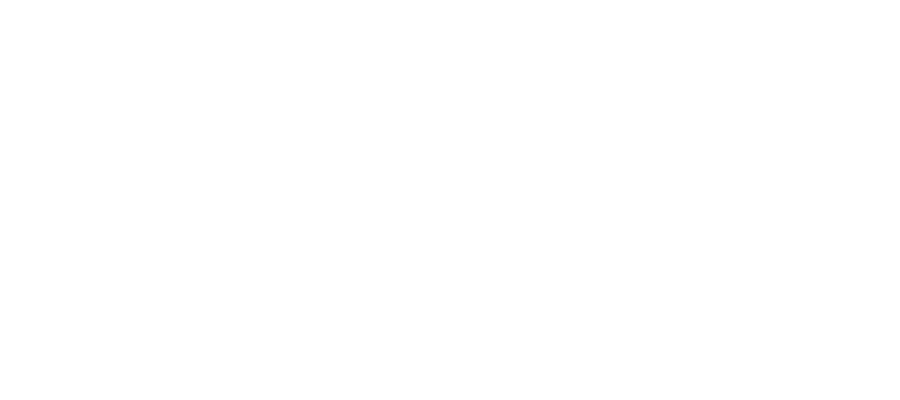

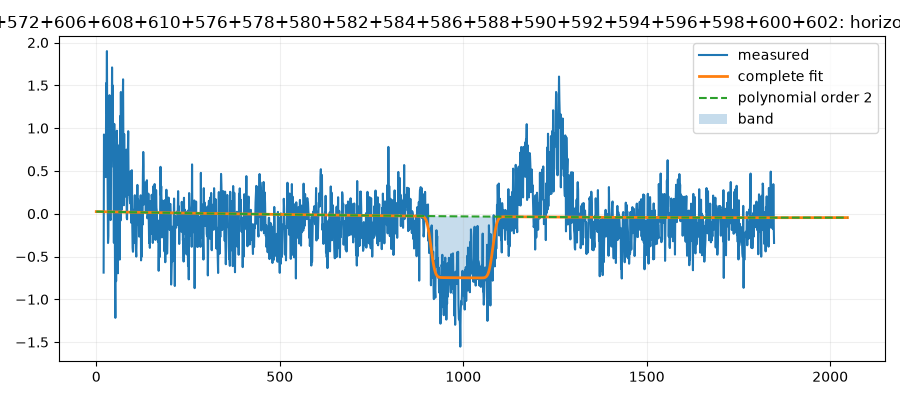

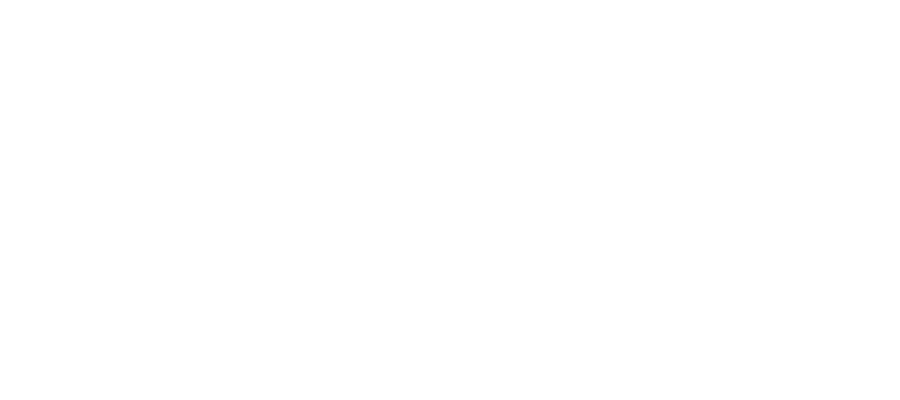

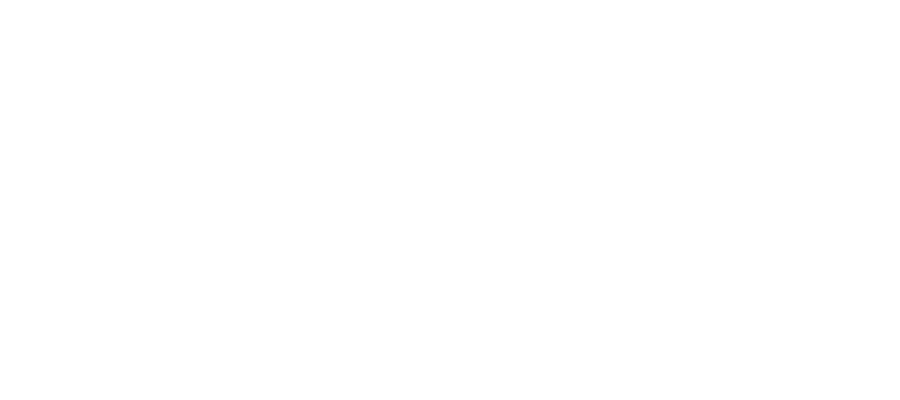

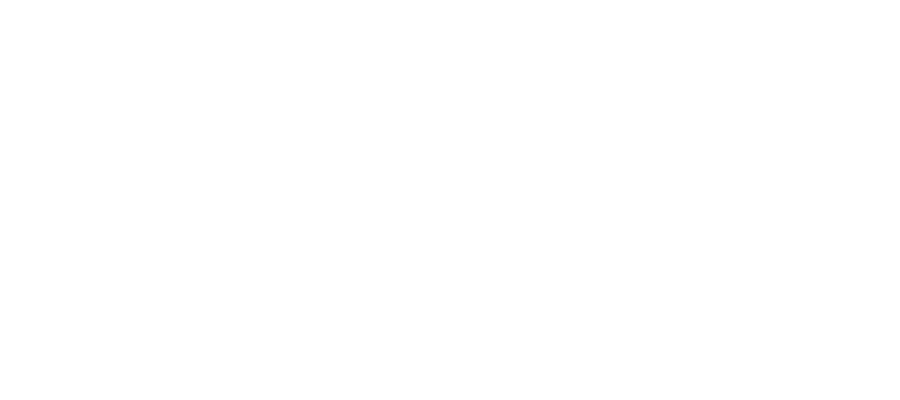

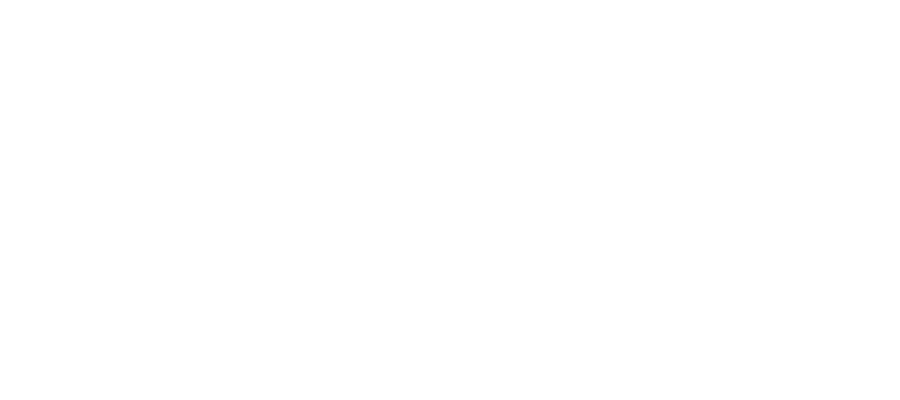

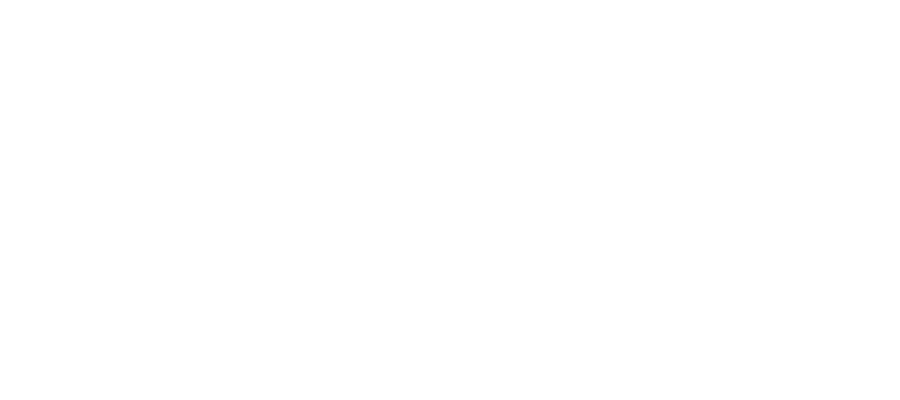

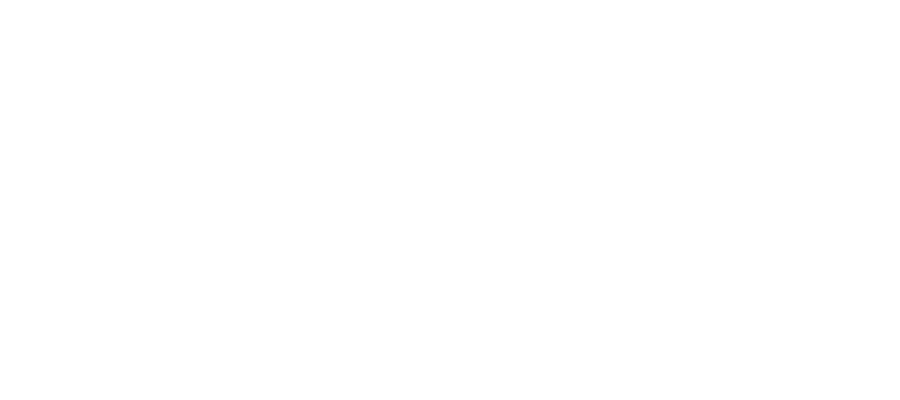

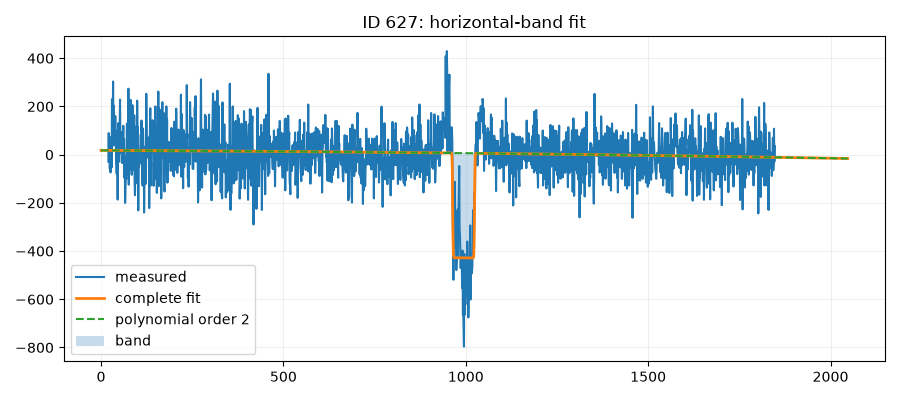

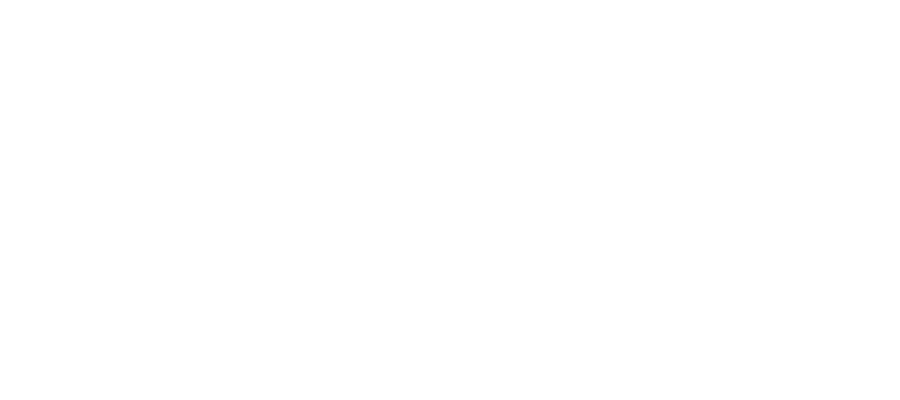

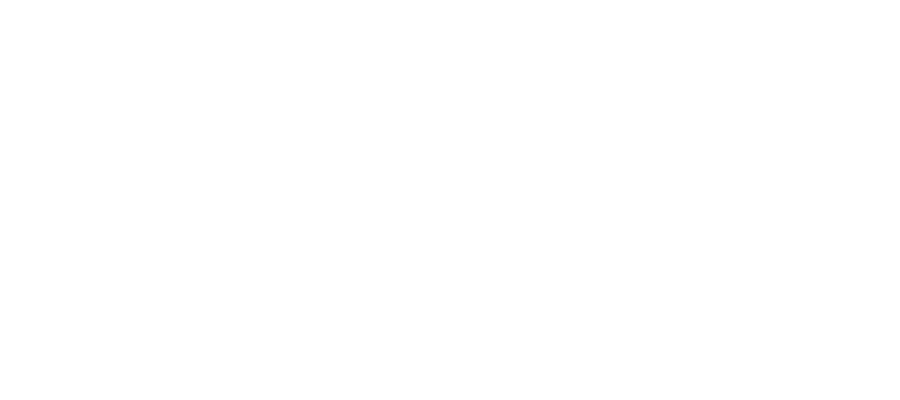

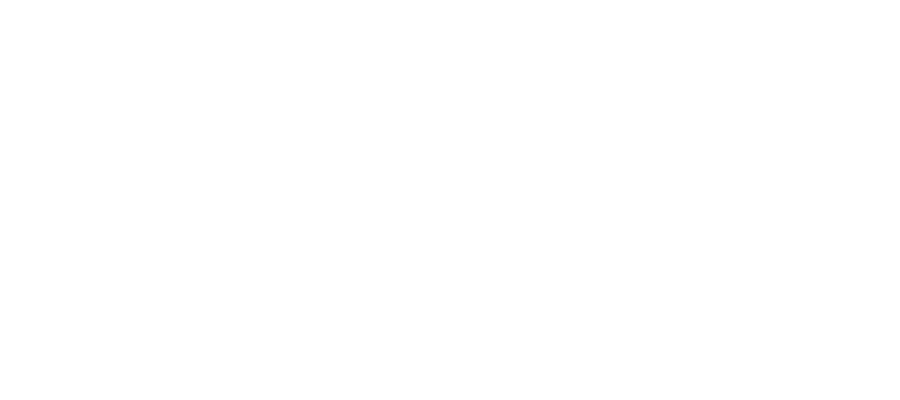

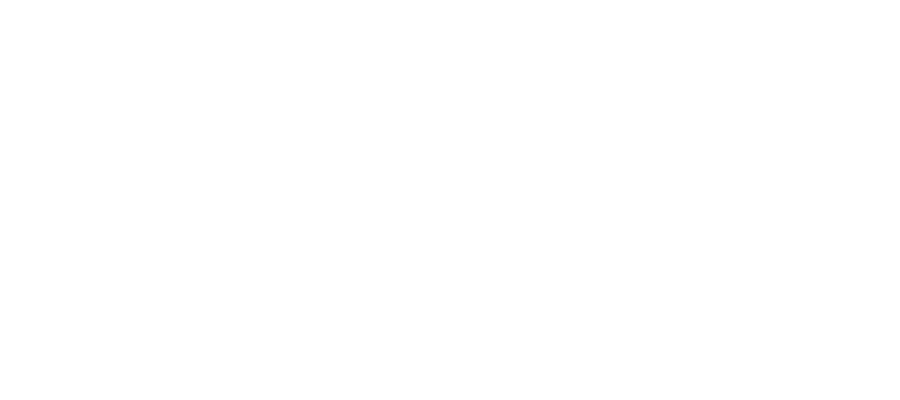

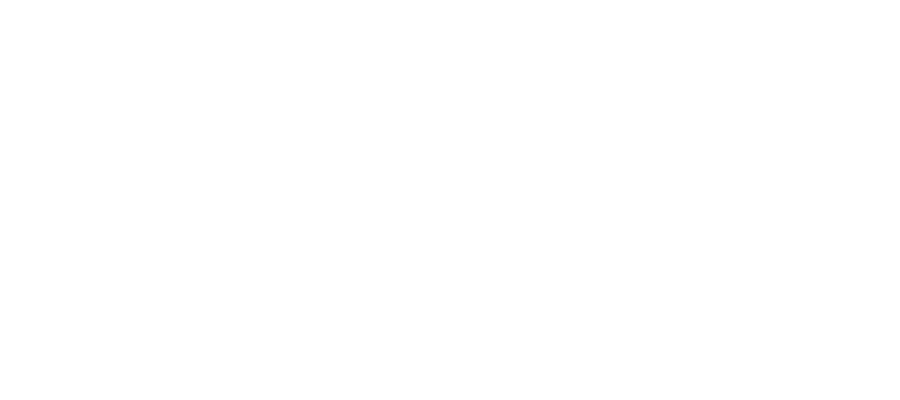

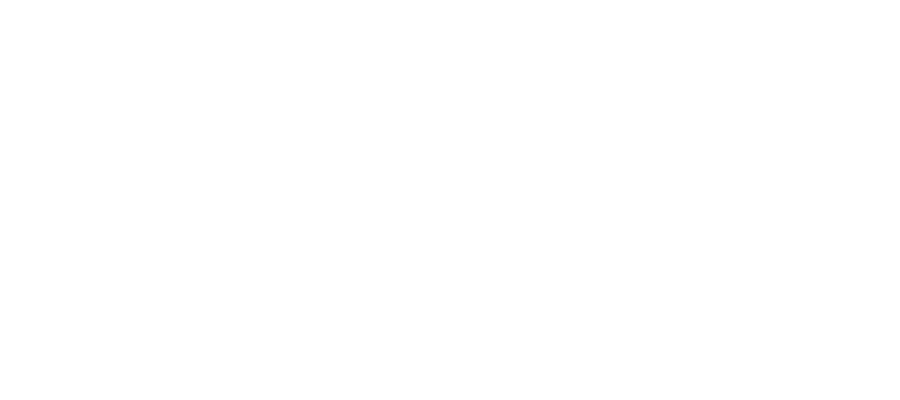

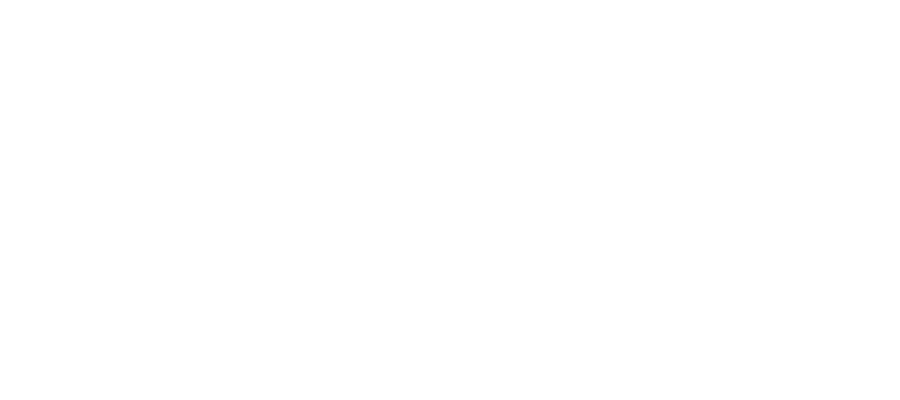

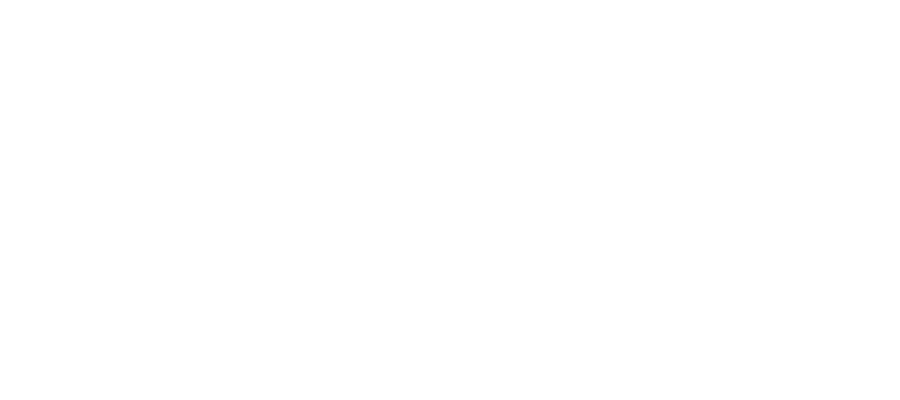

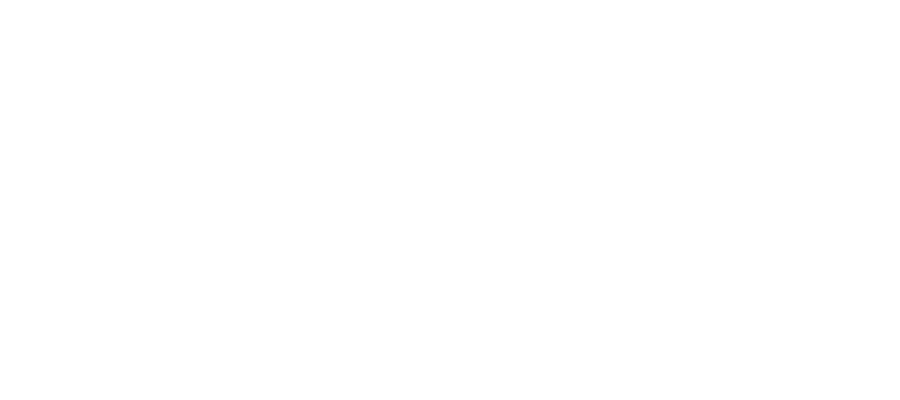

In [40]:
# The band algorithm is always available; disable it without deleting code.
CORRECT_HORIZONTAL_BAND = True
BAND_EDGE_COLUMNS = 20
BAND_SKIPPED_EDGE_COLUMNS = 0
BAND_POLYNOMIAL_ORDER = 2
BAND_CENTER = 1024
BAND_WIDTH = 80
BAND_EDGE = 11
SUBTRACT_POLYNOMIAL_BACKGROUND = False

if CORRECT_HORIZONTAL_BAND:
    corrected_frames = []
    for frame, mask_detector, mask_pixel in zip(frames, mask_detectors, mask_pixels):
        band_mask = mask_pixel.copy()
        band_mask[:20, :] = 1
        band_mask[-200:, :] = 1
        fit = fit_horizontal_band(
            frame.image,
            edge_columns=BAND_EDGE_COLUMNS,
            skipped_edge_columns=BAND_SKIPPED_EDGE_COLUMNS,
            polynomial_order=BAND_POLYNOMIAL_ORDER,
            band_center=BAND_CENTER,
            band_width=BAND_WIDTH,
            band_edge=BAND_EDGE,
            mask=band_mask,
        )
        corrected_image = frame.image - fit.band_image
        if SUBTRACT_POLYNOMIAL_BACKGROUND:
            corrected_image -= fit.polynomial_image
        corrected_frames.append(Frame(frame.image_id, corrected_image, frame.exposure, frame.source))

        fig, axis = plt.subplots(figsize=(9, 4))
        axis.plot(fit.rows, fit.measured_profile, label="measured")
        axis.plot(fit.rows, fit.fitted_profile, linewidth=2, label="complete fit")
        axis.plot(fit.rows, fit.polynomial_profile, "--", label=f"polynomial order {BAND_POLYNOMIAL_ORDER}")
        axis.fill_between(fit.rows, fit.polynomial_profile, fit.fitted_profile, alpha=0.25, label="band")
        axis.set_title(f"ID {frame.image_id}: horizontal-band fit")
        axis.legend()
        axis.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
    frames = corrected_frames



## Choose references and fitting parameters


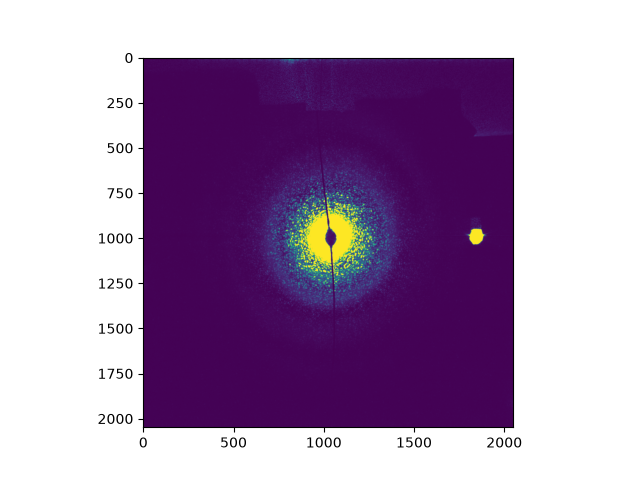

In [42]:
plt.close("all")
fig,ax=plt.subplots()
ax.imshow(frames[1].image, vmin=0, vmax=100)

In [43]:
# Select the reference rows here, immediately before stitching.
PLUS_REFERENCE_INPUT = 0
MINUS_REFERENCE_INPUT = 1
for reference_input, polarization in (
    (PLUS_REFERENCE_INPUT, "+"), (MINUS_REFERENCE_INPUT, "-")
):
    if not 0 <= reference_input < len(IMAGE_ID_GROUPS):
        raise ValueError("Reference input index is outside IMAGE_ID_GROUPS")
    if POLARIZATIONS[reference_input] != polarization:
        raise ValueError(f"Reference input {reference_input} is not polarization {polarization}")

# Registration and intensity fitting use only this central mutually valid ROI.
FIND_IMAGE_SHIFTS = True
MAX_IMAGE_SHIFT = 10.0
REGISTRATION_UPSAMPLE = 10
FIT_ORDER = 1  # 1 = factor + offset; 2 or higher = polynomial mapping.
FIT_PERCENTILES = (2, 98)
DEFAULT_FIT_ROI = np.s_[800:-800, 800:-800]
FIT_ROIS = [DEFAULT_FIT_ROI for _ in frames]

## Inspect registration and intensity fits one input at a time

Choose an input and adjust the rectangular ROI. Press **Evaluate and store ROI**
to register that image to the first image of the same polarization and display
the aligned image, valid overlap, residual, and intensity scatter/fit. Both
combined `mask_pixel` arrays are always excluded from registration and fitting.
Each input keeps its own ROI in `FIT_ROIS`; the final stitching cell uses them.


In [44]:
plt.close("all")

# Fit-widget display parameters live beside the widget.
FIT_WIDGET_PERCENTILES = (1, 99.9)
FIT_WIDGET_MAX_POINTS = 5000


class StitchFitWidget:
    """Evaluate and store one image-to-reference fit at a time."""

    def __init__(self):
        self.reference_for_input = {}
        for polarization, reference in (("+", PLUS_REFERENCE_INPUT), ("-", MINUS_REFERENCE_INPUT)):
            for index, value in enumerate(POLARIZATIONS):
                if value == polarization:
                    self.reference_for_input[index] = reference

        options = [
            (f"input {i}: {POLARIZATIONS[i]} IDs {group_names[i]}", i)
            for i in range(len(frames))
            if i != self.reference_for_input[i]
        ]
        self.input_widget = widgets.Dropdown(options=options, description="input")
        height, width = frames[0].image.shape
        default_rows = self._slice_bounds(DEFAULT_FIT_ROI[0], height)
        default_columns = self._slice_bounds(DEFAULT_FIT_ROI[1], width)
        self.rows_widget = widgets.IntRangeSlider(
            value=default_rows, min=0, max=height, step=1, description="rows",
            continuous_update=False, layout=widgets.Layout(width="700px"),
        )
        self.columns_widget = widgets.IntRangeSlider(
            value=default_columns, min=0, max=width, step=1, description="columns",
            continuous_update=False, layout=widgets.Layout(width="700px"),
        )
        self.evaluate_button = widgets.Button(
            description="Evaluate and store ROI", button_style="primary"
        )
        self.output = widgets.Output()
        self.input_widget.observe(self._load_stored_roi, names="value")
        self.evaluate_button.on_click(self.evaluate)
        display(widgets.VBox([
            self.input_widget, self.rows_widget, self.columns_widget,
            self.evaluate_button, self.output,
        ]))
        self._load_stored_roi()

    @staticmethod
    def _slice_bounds(value, length):
        start = 0 if value.start is None else value.start % length
        stop = length if value.stop is None else value.stop % length
        return (start, stop)

    def _load_stored_roi(self, change=None):
        index = self.input_widget.value
        height, width = frames[index].image.shape
        roi = FIT_ROIS[index]
        self.rows_widget.value = self._slice_bounds(roi[0], height)
        self.columns_widget.value = self._slice_bounds(roi[1], width)

    def evaluate(self, button=None):
        index = self.input_widget.value
        reference_index = self.reference_for_input[index]
        row_start, row_stop = self.rows_widget.value
        column_start, column_stop = self.columns_widget.value
        roi = np.s_[row_start:row_stop, column_start:column_stop]
        FIT_ROIS[index] = roi

        pair = stitch_images(
            [frames[reference_index], frames[index]],
            [mask_pixels[reference_index], mask_pixels[index]],
            register=FIND_IMAGE_SHIFTS,
            max_shift=MAX_IMAGE_SHIFT,
            upsample_factor=REGISTRATION_UPSAMPLE,
            fit_intensity=FIT_ORDER is not None,
            fit_degree=FIT_ORDER or 1,
            fit_percentiles=FIT_PERCENTILES,
            estimation_rois=[roi, roi],
            use_master_where_valid=False,
        )
        reference, item = pair.prepared_frames
        roi_mask = np.zeros(reference.image.shape, dtype=bool)
        roi_mask[roi] = True
        # The masks remain authoritative: ROI only further restricts valid overlap.
        fit_overlap = reference.valid & item.valid & roi_mask
        difference = np.where(fit_overlap, item.image - reference.image, np.nan)

        moving_values = item.fit_input[fit_overlap]
        reference_values = reference.image[fit_overlap]
        finite = np.isfinite(moving_values) & np.isfinite(reference_values)
        moving_values = moving_values[finite]
        reference_values = reference_values[finite]
        low, high = np.percentile(moving_values, FIT_PERCENTILES)
        selected = (moving_values >= low) & (moving_values <= high)
        step = max(1, selected.sum() // FIT_WIDGET_MAX_POINTS)

        with self.output:
            self.output.clear_output(wait=True)
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            values = item.image[item.valid & np.isfinite(item.image)]
            vmin, vmax = np.percentile(values, FIT_WIDGET_PERCENTILES)
            residual_limit = np.nanpercentile(np.abs(difference), 99)
            axes[0].imshow(item.image, cmap="viridis", vmin=vmin, vmax=vmax)
            axes[0].set_title(f"aligned input | image shift {item.shift}")
            axes[1].imshow(fit_overlap, cmap="gray", vmin=0, vmax=1)
            axes[1].set_title(f"unmasked fit pixels in ROI: {fit_overlap.sum()}")
            axes[2].imshow(
                difference, cmap="coolwarm", vmin=-residual_limit, vmax=residual_limit
            )
            axes[2].set_title("residual in valid ROI")
            axes[3].scatter(
                moving_values[selected][::step], reference_values[selected][::step],
                s=3, alpha=0.2, label="unmasked ROI pixels",
            )
            fit_x = np.linspace(low, high, 300)
            axes[3].plot(
                fit_x, np.polyval(item.coefficients, fit_x), color="red", linewidth=2,
                label=f"order {len(item.coefficients) - 1}",
            )
            axes[3].set_xlabel("input intensity")
            axes[3].set_ylabel("reference intensity")
            axes[3].legend()
            for axis in axes[:3]:
                axis.set_axis_off()
            fig.suptitle(
                f"input {index} -> reference {reference_index} | coefficients {item.coefficients}"
            )
            plt.tight_layout()
            plt.show()
            print(f"Stored FIT_ROIS[{index}] = np.s_[{row_start}:{row_stop}, {column_start}:{column_stop}]")


fit_widget = StitchFitWidget()


## Run final stitching with the stored mask shifts and per-image fit ROIs


In [45]:
stitch_results = []
stitched_image_ids = []
for polarization, reference_index in (
    ("+", PLUS_REFERENCE_INPUT),
    ("-", MINUS_REFERENCE_INPUT),
):
    selected = [index for index, value in enumerate(POLARIZATIONS) if value == polarization]
    if reference_index not in selected:
        raise ValueError(f"Reference input {reference_index} is not a {polarization} image")
    selected.remove(reference_index)
    selected.insert(0, reference_index)

    selected_frames = [frames[index] for index in selected]
    selected_masks = [mask_pixels[index] for index in selected]
    selected_fit_rois = [FIT_ROIS[index] for index in selected]
    result = stitch_images(
        selected_frames,
        selected_masks,
        register=FIND_IMAGE_SHIFTS,
        max_shift=MAX_IMAGE_SHIFT,
        upsample_factor=REGISTRATION_UPSAMPLE,
        fit_intensity=FIT_ORDER is not None,
        fit_degree=FIT_ORDER or 1,
        fit_percentiles=FIT_PERCENTILES,
        estimation_rois=selected_fit_rois,
        use_master_where_valid=True,
    )
    stitch_results.append(result)
    stitched_image_ids.append([group_id_lists[index] for index in selected])
    print(f"Polarization {polarization}; reference input {reference_index}, IDs {group_id_lists[reference_index]}")
    for item in result.prepared_frames:
        print(f"  ID {item.image_id}: shift={item.shift}, coefficients={item.coefficients}")


Polarization +; reference input 0, IDs [569, 571, 605, 607, 609, 575, 577, 579, 581, 583, 585, 587, 589, 591, 593, 595, 597, 599, 601]
  ID 569+571+605+607+609+575+577+579+581+583+585+587+589+591+593+595+597+599+601: shift=(0.0, 0.0), coefficients=(1.0, 0.0)
  ID 660+662+664+666+668+670+672+674+676+678+680+682+684+686+688+690+692+694+696+698+700+702+704+706+708: shift=(0.1, -0.1), coefficients=(0.028952721872677147, -1.73857585238771)
  ID 617: shift=(0.1, 0.0), coefficients=(0.0265531588347686, -3.3013209956040073)
  ID 622+625: shift=(0.2, 0.0), coefficients=(0.026900973977086882, -3.9025867732453605)
  ID 627: shift=(0.2, 0.0), coefficients=(0.02707206109364012, -4.044332314107192)
  ID 630+633: shift=(0.2, 0.0), coefficients=(0.027452171807083644, -3.3598394014459187)
  ID 635: shift=(0.2, 0.0), coefficients=(0.027516822279884074, -3.9038374998605505)
  ID 638: shift=(0.2, 0.0), coefficients=(0.02739185394331868, -2.195695413523696)
  ID 641: shift=(0.2, 0.0), coefficients=(0.02715

## Inspect alignment, normalization fits, and overlap


In [48]:
DISPLAY_PERCENTILES = (1, 99.9)


def show_stored_fit(input_index):
    """Show one stored final fit; masks and that input's ROI remain excluded."""
    polarization = POLARIZATIONS[input_index]
    result = stitch_results[0 if polarization == "+" else 1]
    selected = [i for i, value in enumerate(POLARIZATIONS) if value == polarization]
    reference_index = PLUS_REFERENCE_INPUT if polarization == "+" else MINUS_REFERENCE_INPUT
    selected.remove(reference_index)
    selected.insert(0, reference_index)
    item = result.prepared_frames[selected.index(input_index)]
    reference = result.prepared_frames[0]
    roi_region = np.zeros(reference.image.shape, dtype=bool)
    roi_region[FIT_ROIS[input_index]] = True
    overlap = reference.valid & item.valid & roi_region
    difference = np.where(overlap, item.image - reference.image, np.nan)
    values = item.image[item.valid & np.isfinite(item.image)]
    vmin, vmax = np.percentile(values, DISPLAY_PERCENTILES)
    limit = np.nanpercentile(np.abs(difference), 99) if overlap.any() else 1

    moving_values = item.fit_input[overlap]
    reference_values = reference.image[overlap]
    finite = np.isfinite(moving_values) & np.isfinite(reference_values)
    moving_values, reference_values = moving_values[finite], reference_values[finite]
    low, high = np.percentile(moving_values, FIT_PERCENTILES)
    fitted = (moving_values >= low) & (moving_values <= high)
    step = max(1, fitted.sum() // 5000)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(item.image, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"aligned input; shift {item.shift}")
    axes[1].imshow(overlap, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"unmasked overlap inside ROI: {overlap.sum()}")
    axes[2].imshow(difference, cmap="coolwarm", vmin=-limit, vmax=limit)
    axes[2].set_title("residual in fit pixels")
    axes[3].scatter(
        moving_values[fitted][::step], reference_values[fitted][::step],
        s=3, alpha=0.2, label="fit pixels",
    )
    fit_x = np.linspace(low, high, 300)
    axes[3].plot(fit_x, np.polyval(item.coefficients, fit_x), "r-", linewidth=2,
                 label=f"order {len(item.coefficients) - 1}")
    axes[3].set_xlabel("input intensity")
    axes[3].set_ylabel("reference intensity")
    axes[3].legend()
    for axis in axes[:3]:
        axis.set_axis_off()
    fig.suptitle(f"input {input_index}, IDs {group_names[input_index]} -> reference {reference_index}")
    plt.tight_layout()
    plt.show()


fit_result_widget = widgets.Dropdown(
    options=[(f"input {i}: IDs {name}", i) for i, name in enumerate(group_names)],
    description="inspect",
)
widgets.interact(show_stored_fit, input_index=fit_result_widget)


interactive(children=(Dropdown(description='inspect', options=(('input 0: IDs 569+571+605+607+609+575+577+579+…

<function __main__.show_stored_fit(input_index)>

## Inspect the final combined images


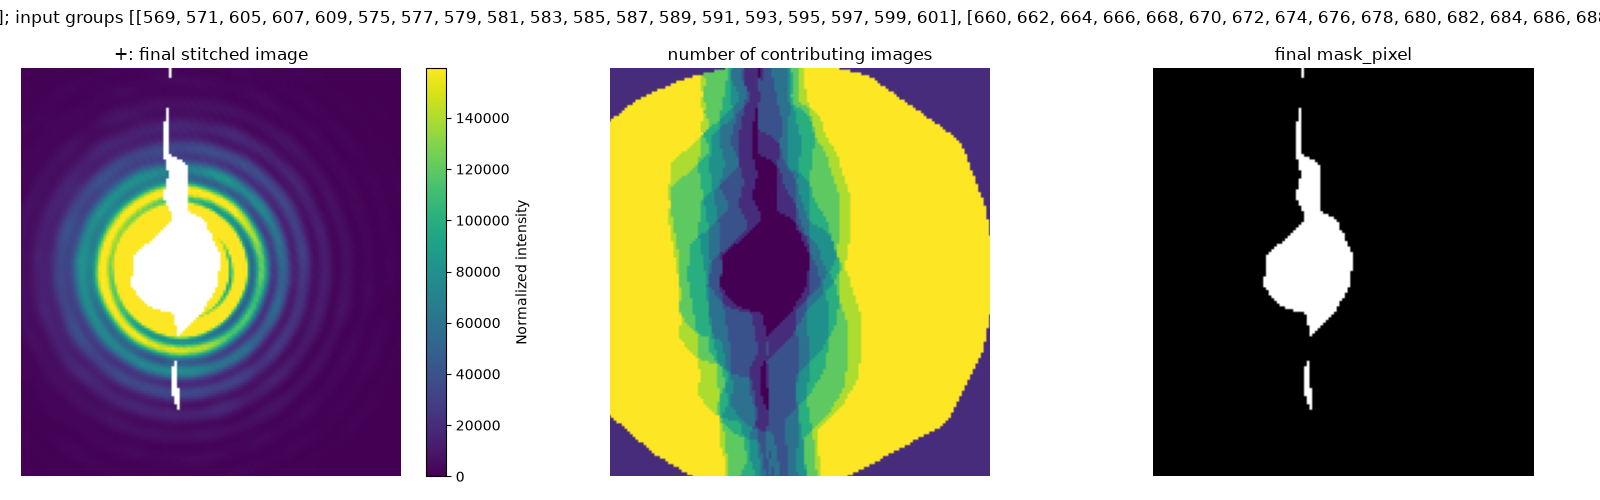

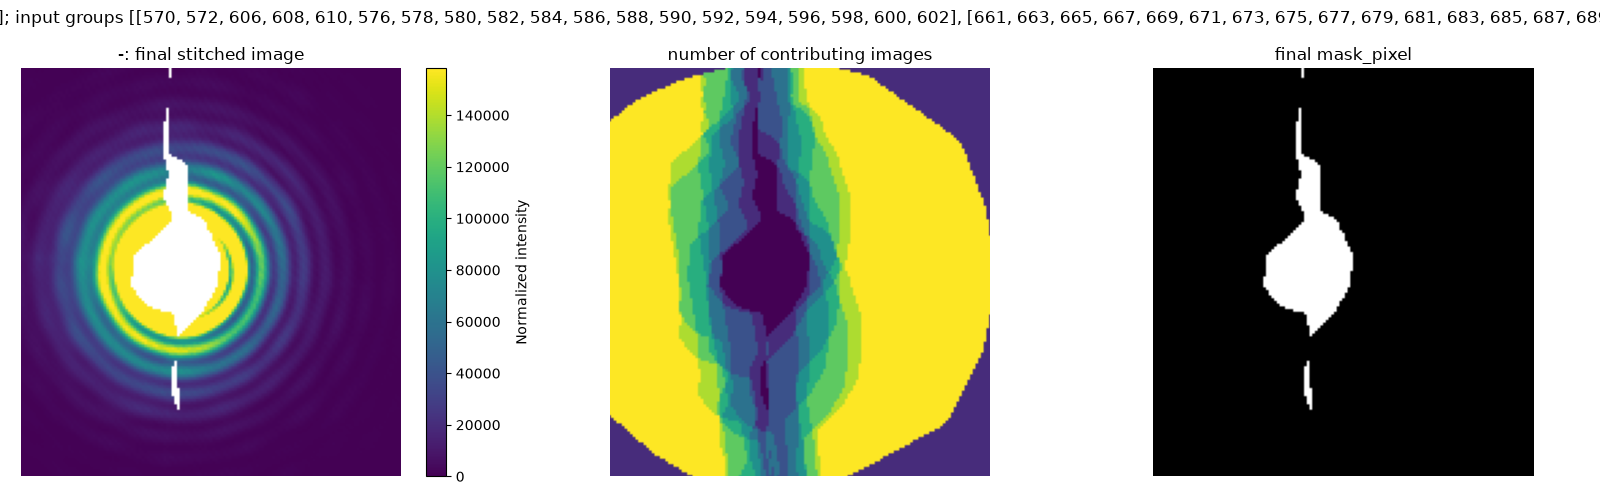

In [47]:
plt.close("all")

for polarization, image_ids, result in zip(("+", "-"), stitched_image_ids, stitch_results):
    image_values = result.image[result.missing_mask == 0]
    vmin, vmax = np.percentile(image_values, (1, 99.975))
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
    shown = axes[0].imshow(result.image, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{polarization}: final stitched image")
    fig.colorbar(shown, ax=axes[0], label="Normalized intensity")
    axes[1].imshow(result.source_count, cmap="viridis")
    axes[1].set_title("number of contributing images")
    axes[2].imshow(result.missing_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("final mask_pixel")
    for axis in axes:
        axis.set_axis_off()
        axis.set_xlim(980,1120)
        axis.set_ylim(920,1070)
    fig.suptitle(f"Reference IDs {image_ids[0]}; input groups {image_ids}")
    plt.tight_layout()
    plt.show()

In [63]:
plt.close("all")

import CCI_core as cci
import reconstruct as rec
import fth_reconstruction as fth

pos=np.array(stitch_results[0].image)
neg=np.array(stitch_results[1].image)
pos=np.nan_to_num(pos)
pos=cci.shift_image(pos, [1024+995,1024+1039]) 
neg=np.nan_to_num(neg)
neg=cci.shift_image(neg, [1024+995,1024+1039]) 

In [64]:
neg=np.nan_to_num(neg)
pos=np.nan_to_num(pos)

In [65]:
fig,ax=plt.subplots()

ax.imshow(np.real(fth.reconstruct(pos-neg)))

In [67]:
plt.close("all")
%matplotlib qt
prop_dist, phase, dx, dy = -5, -0.27 - np.pi, 0, 0.0
focus_operation = "-"
roi_s=np.s_[320:580,220:460]

#roi_s=np.s_[:,:]
focus_sliders = rec.focusCDI(
    pos,
    neg,
    roi_s,
    mask=1,
    phase=phase,
    prop_dist=prop_dist,
    dx=dx,
    dy=dy,
    operation=focus_operation,
    max_prop_dist=30,
    scale=(2, 98),
)
slider_prop, slider_phase, slider_dx, slider_dy = focus_sliders[:4]

interactive(children=(FloatSlider(value=-5.0, description='propagation[um]', layout=Layout(width='90%'), max=3…

## Simple names for interactive inspection

The names below are intentionally stable. Use them directly in later cells; no knowledge of the stitching loops is required.


In [53]:
pos_reference = np.asarray(frames[PLUS_REFERENCE_INPUT].image, dtype=float)
neg_reference = np.asarray(frames[MINUS_REFERENCE_INPUT].image, dtype=float)
mask_pos_reference = np.asarray(mask_pixels[PLUS_REFERENCE_INPUT], dtype=np.uint8)
mask_neg_reference = np.asarray(mask_pixels[MINUS_REFERENCE_INPUT], dtype=np.uint8)

pos = np.asarray(stitch_results[0].image, dtype=float)
neg = np.asarray(stitch_results[1].image, dtype=float)
mask_pos = np.asarray(stitch_results[0].missing_mask, dtype=np.uint8)
mask_neg = np.asarray(stitch_results[1].missing_mask, dtype=np.uint8)


def show_image(image, title="image", percentiles=(1, 99.9)):
    """Display any 2-D NumPy image with a useful linear intensity range."""
    image = np.asarray(image, dtype=float)
    finite = image[np.isfinite(image)]
    vmin, vmax = np.percentile(finite, percentiles)
    fig, axis = plt.subplots(figsize=(6, 5))
    shown = axis.imshow(image, cmap="viridis", vmin=vmin, vmax=vmax)
    axis.set_title(title)
    axis.set_axis_off()
    fig.colorbar(shown, ax=axis, label="Intensity")
    plt.tight_layout()
    plt.show()
    return fig, axis


def show_input(input_number):
    """Display one averaged, dark-corrected stitching input and its mask."""
    show_image(frames[input_number].image, f"input {input_number}: IDs {group_id_lists[input_number]}")


print("Easy NumPy names: pos_reference, neg_reference, pos, neg")
print("Easy mask names: mask_pos_reference, mask_neg_reference, mask_pos, mask_neg")
print("Examples: show_input(2) or show_image(pos, 'stitched positive')")


Easy NumPy names: pos_reference, neg_reference, pos, neg
Easy mask names: mask_pos_reference, mask_neg_reference, mask_pos, mask_neg
Examples: show_input(2) or show_image(pos, 'stitched positive')


## Save files for 01_FTH.ipynb

In [54]:
OUTPUT_FOLDER = join(BASEFOLDER, "processed", "stitched")
OUTPUT_NAME = "moved_beamstop"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def roi_as_bounds(roi, shape):
    """Store a NumPy ROI as explicit (row_start, row_stop, column_start, column_stop)."""
    row_start, row_stop, _ = roi[0].indices(shape[0])
    column_start, column_stop, _ = roi[1].indices(shape[1])
    return row_start, row_stop, column_start, column_stop


output_files = []
for polarization, image_ids, result in zip(("+", "-"), stitched_image_ids, stitch_results):
    name = "plus" if polarization == "+" else "minus"
    output_file = join(OUTPUT_FOLDER, f"stitched_{OUTPUT_NAME}_{name}_{USER}.npz")
    fit_coefficients = np.asarray([item.coefficients for item in result.prepared_frames], dtype=float)
    # Keep both kinds of displacement explicit: the user moves beamstop masks,
    # while registration moves complete images and their masks to the reference.
    reference_input = PLUS_REFERENCE_INPUT if polarization == "+" else MINUS_REFERENCE_INPUT
    selected_inputs = [i for i, value in enumerate(POLARIZATIONS) if value == polarization]
    selected_inputs.remove(reference_input)
    selected_inputs.insert(0, reference_input)
    mask_shifts = np.asarray([MASK_SHIFTS[i] for i in selected_inputs], dtype=float)
    image_shifts = np.asarray([item.shift for item in result.prepared_frames], dtype=float)
    fit_roi_bounds = np.asarray(
        [roi_as_bounds(FIT_ROIS[i], result.image.shape) for i in selected_inputs],
        dtype=int,
    )
    factors = fit_coefficients[:, 0] if FIT_ORDER == 1 else np.full(len(image_ids), np.nan)
    offsets = fit_coefficients[:, -1]

    # Save the complete mask history in the same order as the stitched inputs.
    input_mask_detectors = np.stack(
        [np.asarray(mask_detectors[i], dtype=np.uint8) for i in selected_inputs]
    )
    input_mask_beamstops_unshifted = np.stack(
        [np.asarray(unshifted_mask_beamstops[i], dtype=np.uint8) for i in selected_inputs]
    )
    input_mask_beamstops_shifted = np.stack(
        [np.asarray(mask_beamstops[i], dtype=np.uint8) for i in selected_inputs]
    )
    input_mask_pixels = np.stack(
        [np.asarray(mask_pixels[i], dtype=np.uint8) for i in selected_inputs]
    )
    aligned_input_mask_pixels = np.stack(
        [(~np.asarray(item.valid, dtype=bool)).astype(np.uint8)
         for item in result.prepared_frames]
    )

    # A pixel remains masked by stitching only if every aligned input masks it.
    mask_stitched_intersection = np.logical_and.reduce(
        aligned_input_mask_pixels.astype(bool), axis=0
    ).astype(np.uint8)

    # mask_detector is a fixed detector property and is always added at the end.
    mask_detector = np.maximum.reduce(input_mask_detectors).astype(np.uint8)
    mask_beamstop = (
        (mask_stitched_intersection > 0) & (mask_detector == 0)
    ).astype(np.uint8)
    mask_pixel_stitched = np.clip(
        mask_detector + mask_stitched_intersection, 0, 1
    ).astype(np.uint8)
    mask_pixel = mask_pixel_stitched  # Standard name loaded by 01_FTH.

    reference_ids = image_ids[0]
    reference_exposure = frames[reference_input].exposure
    np.savez_compressed(
        output_file,
        image=result.image,
        mask_detector=mask_detector,
        mask_beamstop=mask_beamstop,
        mask_pixel=mask_pixel,
        mask_pixel_stitched=mask_pixel_stitched,
        mask_stitched_intersection=mask_stitched_intersection,
        input_mask_detectors=input_mask_detectors,
        input_mask_beamstops_unshifted=input_mask_beamstops_unshifted,
        input_mask_beamstops_shifted=input_mask_beamstops_shifted,
        input_mask_pixels=input_mask_pixels,
        aligned_input_mask_pixels=aligned_input_mask_pixels,
        source_count=result.source_count,
        reference_exposure=float(reference_exposure),
        reference_image_id=int(reference_ids[0]),
        reference_image_ids=np.asarray(reference_ids, dtype=int),
        ordered_input_groups=np.asarray(["+".join(map(str, ids)) for ids in image_ids]),
        ordered_input_kinds=np.asarray([INPUT_KINDS[i] for i in selected_inputs]),
        beamstop_mask_dilations=np.asarray(
            [BEAMSTOP_MASK_DILATIONS[i] for i in selected_inputs], dtype=int
        ),
        ordered_dark_groups=np.asarray([str(DARK_ID_GROUPS[i]) for i in selected_inputs]),
        polarization=np.asarray(polarization),
        mask_shifts=mask_shifts,
        image_shifts=image_shifts,
        fit_roi_bounds=fit_roi_bounds,
        fit_order=-1 if FIT_ORDER is None else FIT_ORDER,
        fit_coefficients=fit_coefficients,
        factors=factors,
        offsets=offsets,
        energy_eV=energy_eV,
    )
    output_files.append(output_file)
    print(f"Saved {polarization}: {output_file}")

print("Use these as PLUS_STITCHED_FILE and MINUS_STITCHED_FILE in 01_FTH:")
for polarization, output_file in zip(("+", "-"), output_files):
    print(f"  {polarization}: {os.path.relpath(output_file, BASEFOLDER)}")


Saved +: /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/processed/stitched/stitched_moved_beamstop_plus_rb.npz
Saved -: /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/processed/stitched/stitched_moved_beamstop_minus_rb.npz
Use these as PLUS_STITCHED_FILE and MINUS_STITCHED_FILE in 01_FTH:
  +: processed/stitched/stitched_moved_beamstop_plus_rb.npz
  -: processed/stitched/stitched_moved_beamstop_minus_rb.npz


In [55]:
print("image ID groups:", IMAGE_ID_GROUPS)
print("input kinds:", INPUT_KINDS)
print("dark ID groups (ignored for preprocessed entries):", DARK_ID_GROUPS)
print("plus reference input:", PLUS_REFERENCE_INPUT, group_id_lists[PLUS_REFERENCE_INPUT])
print("minus reference input:", MINUS_REFERENCE_INPUT, group_id_lists[MINUS_REFERENCE_INPUT])
print("beamstop mask dilations:", BEAMSTOP_MASK_DILATIONS)
print("stored mask shifts:", MASK_SHIFTS)
print("stored fit ROI bounds:")
for input_index, roi in enumerate(FIT_ROIS):
    print(f"  input {input_index}:", roi_as_bounds(roi, frames[input_index].image.shape))


image ID groups: [[569, 571, 605, 607, 609, np.int64(575), np.int64(577), np.int64(579), np.int64(581), np.int64(583), np.int64(585), np.int64(587), np.int64(589), np.int64(591), np.int64(593), np.int64(595), np.int64(597), np.int64(599), np.int64(601)], [570, 572, 606, 608, 610, np.int64(576), np.int64(578), np.int64(580), np.int64(582), np.int64(584), np.int64(586), np.int64(588), np.int64(590), np.int64(592), np.int64(594), np.int64(596), np.int64(598), np.int64(600), np.int64(602)], [np.int64(660), np.int64(662), np.int64(664), np.int64(666), np.int64(668), np.int64(670), np.int64(672), np.int64(674), np.int64(676), np.int64(678), np.int64(680), np.int64(682), np.int64(684), np.int64(686), np.int64(688), np.int64(690), np.int64(692), np.int64(694), np.int64(696), np.int64(698), np.int64(700), np.int64(702), np.int64(704), np.int64(706), np.int64(708)], [np.int64(661), np.int64(663), np.int64(665), np.int64(667), np.int64(669), np.int64(671), np.int64(673), np.int64(675), np.int64(6